In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.21.0
All libraries loaded successfully!


In [10]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

classes = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("CIFAR-10 Dataset Summary:")
print(f"Training images   : {x_train.shape[0]:,}")
print(f"Test images       : {x_test.shape[0]:,}")
print(f"Image dimensions  : {x_train.shape[1]} x {x_train.shape[2]} pixels")
print(f"Color channels    : {x_train.shape[3]} (RGB)")
print(f"Number of classes : {len(classes)}")
print(f"Classes           : {', '.join(classes)}")
print(f"Pixel value range : {x_train.min()} to {x_train.max()}")

CIFAR-10 Dataset Summary:
Training images   : 50,000
Test images       : 10,000
Image dimensions  : 32 x 32 pixels
Color channels    : 3 (RGB)
Number of classes : 10
Classes           : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
Pixel value range : 0 to 255


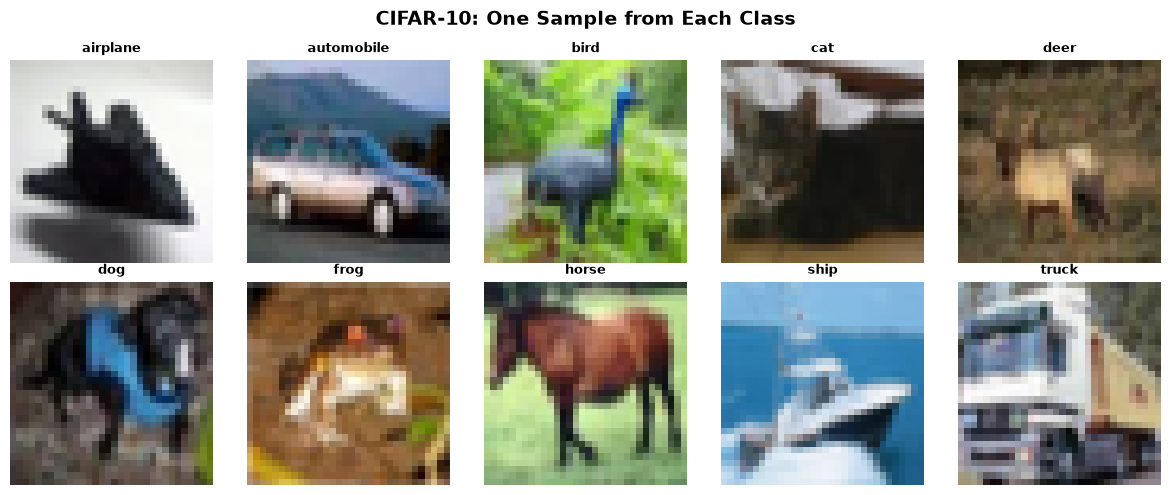

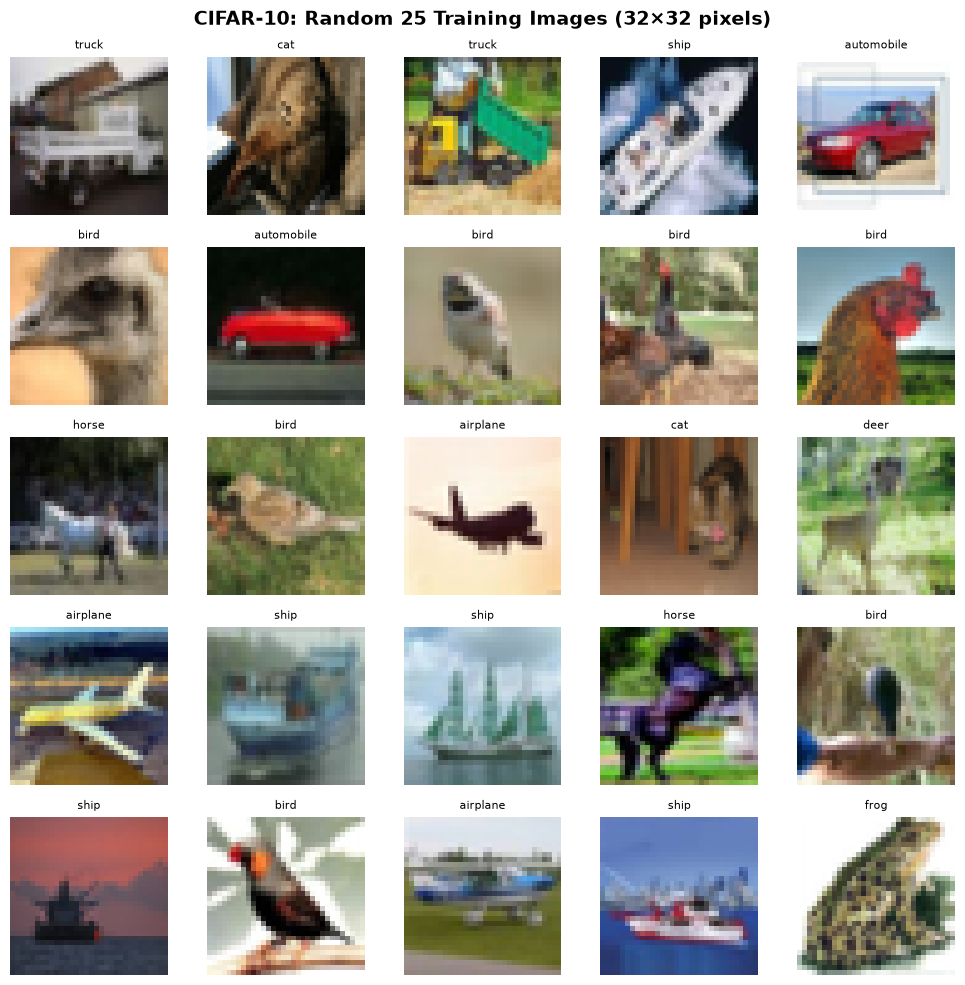

In [16]:
plt.figure(figsize=(12, 5))
plt.suptitle('CIFAR-10: One Sample from Each Class', fontsize=14, fontweight='bold')

for i in range(10):
    sample_id = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[sample_id])
    plt.title(f'{classes[i]}', fontsize=9, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))
plt.suptitle('CIFAR-10: Random 25 Training Images (32×32 pixels)', 
             fontsize=14, fontweight='bold')
indices = np.random.choice(len(x_train), 25, replace=False)
for i, id in enumerate(indices):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[id])
    plt.title(classes[y_train[id][0]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0


x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)  # 32*32*3 = 3072
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalization Results:")
print(f"  Original pixel range   : [{x_train.min()}, {x_train.max()}]")
print(f"  Normalized pixel range : [{x_train_norm.min():.1f}, {x_train_norm.max():.1f}]")
print()
print("Shape for CNN (keeps 2D structure):")
print(f"  x_train_norm : {x_train_norm.shape}   ← (samples, height, width, channels)")
print()
print("Shape for ANN (flattened to 1D vector):")
print(f"  x_train_flat : {x_train_flat.shape}  ← (samples, 3072)  [32×32×3 = 3072]")

Normalization Results:
  Original pixel range   : [0, 255]
  Normalized pixel range : [0.0, 1.0]

Shape for CNN (keeps 2D structure):
  x_train_norm : (50000, 32, 32, 3)   ← (samples, height, width, channels)

Shape for ANN (flattened to 1D vector):
  x_train_flat : (50000, 3072)  ← (samples, 3072)  [32×32×3 = 3072]


In [18]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),     
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')  
], name='Baseline_ANN')

ann_model.compile(
    optimizer='adam',                          
    loss='sparse_categorical_crossentropy',    
    metrics=['accuracy']
)

ann_model.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("Training Baseline ANN")

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,   
    batch_size=64,           
    verbose=1
)

Training Baseline ANN
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2642 - loss: 1.9991 - val_accuracy: 0.3108 - val_loss: 1.8812
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3178 - loss: 1.8637 - val_accuracy: 0.3412 - val_loss: 1.8166
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3288 - loss: 1.8249 - val_accuracy: 0.3708 - val_loss: 1.7595
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3481 - loss: 1.7826 - val_accuracy: 0.3818 - val_loss: 1.7354
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3549 - loss: 1.7574 - val_accuracy: 0.3762 - val_loss: 1.7471
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3666 - loss: 1.7354 - val_accuracy: 0.3818 - val_loss: 1.7065
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3722 - loss: 1.7180 - val_accuracy: 0.3988 - val_loss: 1.6804
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3840 - loss: 1

In [20]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Results:")
print(f"Test Loss     : {ann_test_loss:.4f}")
print(f"Test Accuracy : {ann_test_acc*100:.2f}%")

ANN Results:
Test Loss     : 1.6152
Test Accuracy : 42.64%


In [21]:
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')

], name='Baseline_CNN')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
print("Training Baseline CNN")

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Training Baseline CNN
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.4547 - loss: 1.5293 - val_accuracy: 0.5652 - val_loss: 1.2185
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.6055 - loss: 1.1271 - val_accuracy: 0.6418 - val_loss: 1.0427
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6694 - loss: 0.9432 - val_accuracy: 0.6876 - val_loss: 0.9694
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.7150 - loss: 0.8084 - val_accuracy: 0.6906 - val_loss: 0.9517
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7533 - loss: 0.7010 - val_accuracy: 0.6922 - val_loss: 0.9945
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7851 - loss: 0.6069 - val_accuracy: 0.7084 - val_loss: 0.9458
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8135 - loss: 0.5233 - val_accuracy: 0.6836 - val_loss: 1.2524
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Results:")
print(f"Test Loss     : {cnn_test_loss:.4f}")
print(f"Test Accuracy : {cnn_test_acc*100:.2f}%")

CNN Results:
Test Loss     : 1.0002
Test Accuracy : 73.48%


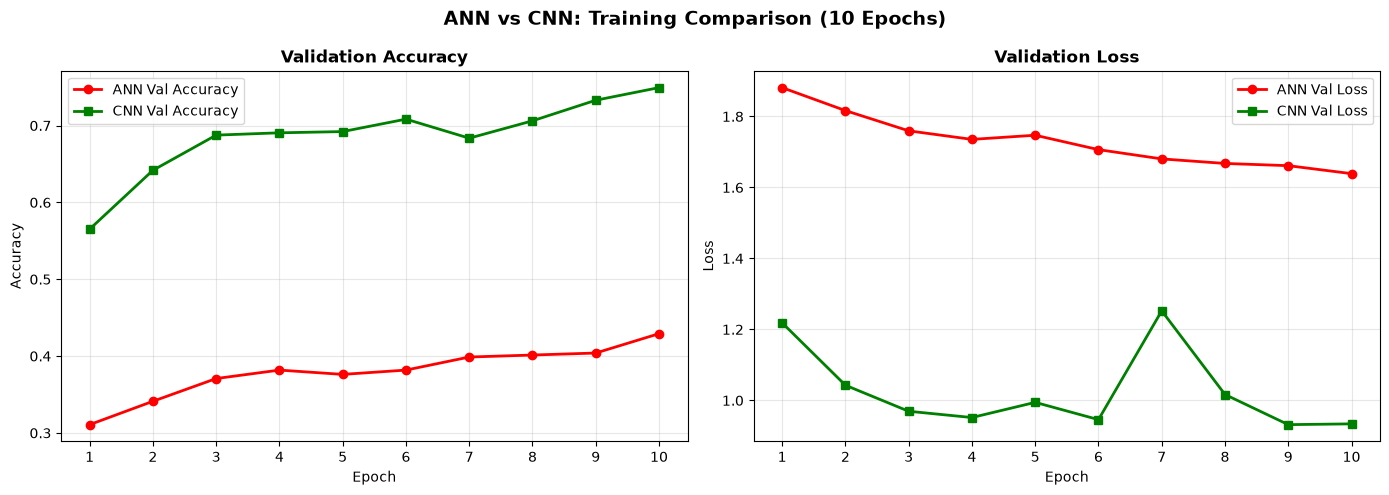


Model        Final Train Acc   Final Val Acc
---------------------------------------------
ANN                   38.67%          42.92%
CNN                   86.91%          74.94%


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN vs CNN: Training Comparison (10 Epochs)', fontsize=14, fontweight='bold')

axes[0].plot(ann_history.history['val_accuracy'], 
             label='ANN Val Accuracy', color='red', marker='o', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], 
             label='CNN Val Accuracy', color='green', marker='s', linewidth=2)
axes[0].set_title('Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(range(1, 11))


axes[1].plot(ann_history.history['val_loss'], 
             label='ANN Val Loss', color='red', marker='o', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], 
             label='CNN Val Loss', color='green', marker='s', linewidth=2)
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(range(1, 11))

plt.tight_layout()
plt.show()

print(f"\n{'Model':<10} {'Final Train Acc':>17} {'Final Val Acc':>15}")
print("-"*45)
print(f"{'ANN':<10} {ann_history.history['accuracy'][-1]*100:>16.2f}% {ann_history.history['val_accuracy'][-1]*100:>14.2f}%")
print(f"{'CNN':<10} {cnn_history.history['accuracy'][-1]*100:>16.2f}% {cnn_history.history['val_accuracy'][-1]*100:>14.2f}%")

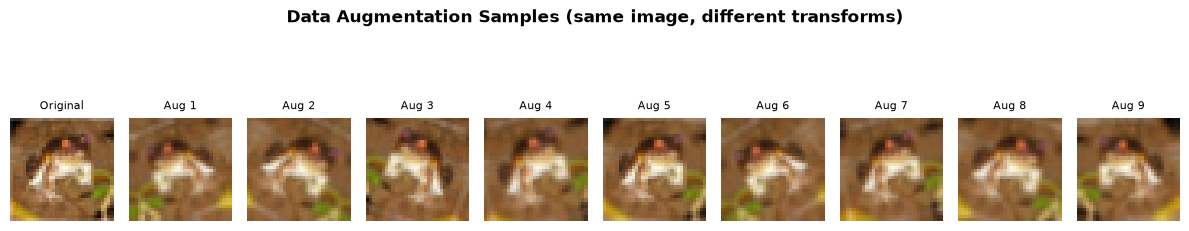

In [28]:

data_augmentation_preview = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

sample_img = x_train_norm[0]
plt.figure(figsize=(12, 3))
plt.suptitle('Data Augmentation Samples (same image, different transforms)', 
             fontweight='bold', fontsize=12)

plt.subplot(1, 10, 1)
plt.imshow(sample_img)
plt.title('Original', fontsize=8)
plt.axis('off')

for i in range(2, 11):
    augmented = data_augmentation_preview(tf.expand_dims(sample_img, 0))[0]
    plt.subplot(1, 10, i)
    plt.imshow(augmented)
    plt.title(f'Aug {i-1}', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentation_layer')

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Augmented CNN")

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Results:")
print(f"Test Loss     : {aug_test_loss:.4f}")
print(f"Test Accuracy : {aug_test_acc*100:.2f}%")

Training Augmented CNN
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.3567 - loss: 1.7929 - val_accuracy: 0.4672 - val_loss: 1.4532
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4634 - loss: 1.4881 - val_accuracy: 0.4932 - val_loss: 1.4749
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5225 - loss: 1.3381 - val_accuracy: 0.5484 - val_loss: 1.3748
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5598 - loss: 1.2438 - val_accuracy: 0.6024 - val_loss: 1.1179
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5901 - loss: 1.1661 - val_accuracy: 0.6420 - val_loss: 1.0515
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 175ms/step - accuracy: 0.6104 - loss: 1.1148 - val_accuracy: 0.6498 - val_loss: 1.0144
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.6287 - loss: 1.0580 - val_accuracy: 0.6872 - val_loss: 0.9020
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy:

In [30]:

ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Deep_ANN_Task1')

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Baseline ANN — Parameters: {ann_model.count_params():,}")
print(f"Deep ANN     — Parameters: {ann_deep.count_params():,}")
print()
print("Training Deep ANN")

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

task1_loss, task1_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"Deep ANN Test Accuracy : {task1_acc*100:.2f}%")
print(f"Baseline ANN Accuracy  : {ann_test_acc*100:.2f}%")
print(f"Improvement            : {(task1_acc - ann_test_acc)*100:+.2f}%")

Baseline ANN — Parameters: 1,707,274
Deep ANN     — Parameters: 3,837,066

Training Deep ANN
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.2071 - loss: 2.1043 - val_accuracy: 0.2568 - val_loss: 1.9636
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2549 - loss: 1.9848 - val_accuracy: 0.2786 - val_loss: 1.9399
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.2694 - loss: 1.9480 - val_accuracy: 0.3286 - val_loss: 1.8854
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2836 - loss: 1.9241 - val_accuracy: 0.3296 - val_loss: 1.9092
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2914 - loss: 1.9093 - val_accuracy: 0.3138 - val_loss: 1.8933
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3002 - loss: 1.8969 - val_accuracy: 0.3408 - val_loss: 1.8753
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3080 - loss: 1.8778 - val_accuracy: 0.3490 - val_loss: 1.84

In [31]:

cnn_scaled = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
  
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Scaled_CNN_Task2')

cnn_scaled.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Baseline CNN   — Parameters: {cnn_model.count_params():,}")
print(f"Scaled CNN     — Parameters: {cnn_scaled.count_params():,}")
print()
print("Training Scaled CNN")

cnn_scaled_history = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

task2_loss, task2_acc = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)
print(f"Scaled CNN Test Accuracy  : {task2_acc*100:.2f}%")
print(f"Baseline CNN Accuracy     : {cnn_test_acc*100:.2f}%")
print(f"Improvement               : {(task2_acc - cnn_test_acc)*100:+.2f}%")

Baseline CNN   — Parameters: 1,144,138
Scaled CNN     — Parameters: 4,569,738

Training Scaled CNN
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 278s 394ms/step - accuracy: 0.4328 - loss: 1.6242 - val_accuracy: 0.5508 - val_loss: 1.2849
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 160ms/step - accuracy: 0.5925 - loss: 1.1551 - val_accuracy: 0.6254 - val_loss: 1.0827
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.6762 - loss: 0.9303 - val_accuracy: 0.6792 - val_loss: 0.9359
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.7285 - loss: 0.7813 - val_accuracy: 0.6714 - val_loss: 0.9938
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.7721 - loss: 0.6487 - val_accuracy: 0.6422 - val_loss: 1.0776
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 94ms/step - accuracy: 0.8094 - loss: 0.5441 - val_accuracy: 0.6690 - val_loss: 1.0097
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 83ms/step - accuracy: 0.8395 - loss: 0.4607 - val_accuracy: 0.6716 - val_

Training CNN for 20 epochs (Task 3)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4432 - loss: 1.5690 - val_accuracy: 0.5126 - val_loss: 1.4763
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5932 - loss: 1.1522 - val_accuracy: 0.6048 - val_loss: 1.1536
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6697 - loss: 0.9495 - val_accuracy: 0.6372 - val_loss: 1.0848
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7149 - loss: 0.8111 - val_accuracy: 0.6882 - val_loss: 0.9248
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7613 - loss: 0.6832 - val_accuracy: 0.7208 - val_loss: 0.8429
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.7875 - loss: 0.6013 - val_accuracy: 0.7168 - val_loss: 0.9101
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8164 - loss: 0.5167 - val_accuracy: 0.6938 - val_loss: 0.9992
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/st

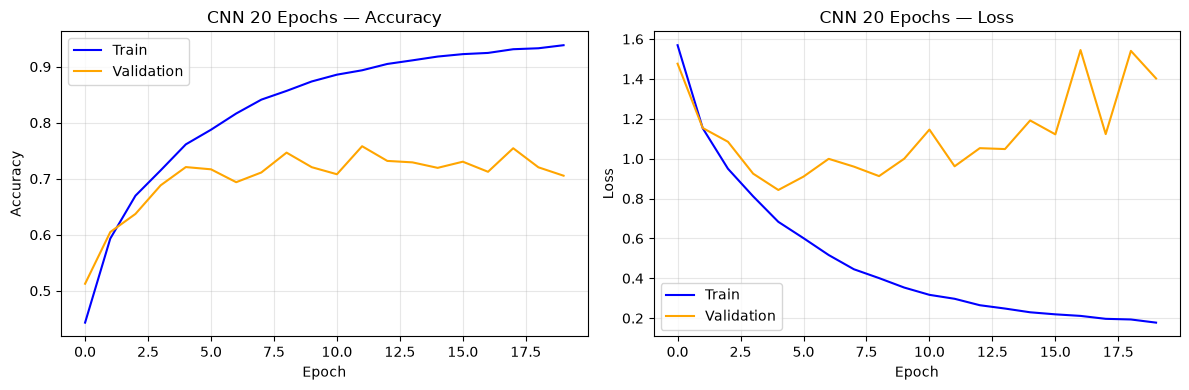

In [32]:

cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_20Epochs_Task3')

cnn_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN for 20 epochs (Task 3)...")

cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,     
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

task3_loss, task3_acc = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN (20 epoch) Test Accuracy  : {task3_acc*100:.2f}%")
print(f"CNN (10 epoch) Test Accuracy  : {cnn_test_acc*100:.2f}%")
print(f"Improvement from 10 more epochs: {(task3_acc - cnn_test_acc)*100:+.2f}%")


plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(cnn_20ep_history.history['accuracy'], label='Train', color='blue')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='Validation', color='orange')
plt.title('CNN 20 Epochs — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(cnn_20ep_history.history['loss'], label='Train', color='blue')
plt.plot(cnn_20ep_history.history['val_loss'], label='Validation', color='orange')
plt.title('CNN 20 Epochs — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping_Task4')

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True,  
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       
    patience=3,      
    min_lr=1e-6,      
    verbose=1
)

print("Training CNN with EarlyStopping")
print("Max epochs allowed: 30, but may stop earlier")

cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=30,                          
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],  
    verbose=1
)

task4_loss, task4_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs = len(cnn_es_history.history['loss'])
print(f"EarlyStopping CNN Results:")
print(f"Trained for {actual_epochs} epochs (out of max 30)")
print(f"Test Accuracy: {task4_acc*100:.2f}%")

Training CNN with EarlyStopping
Max epochs allowed: 30, but may stop earlier
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.4504 - loss: 1.5529 - val_accuracy: 0.5184 - val_loss: 1.4675 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.5939 - loss: 1.1531 - val_accuracy: 0.5502 - val_loss: 1.3518 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6663 - loss: 0.9547 - val_accuracy: 0.6838 - val_loss: 0.9301 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.7158 - loss: 0.8084 - val_accuracy: 0.7158 - val_loss: 0.8483 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.7564 - loss: 0.6934 - val_accuracy: 0.6592 - val_loss: 1.0692 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7888 - loss: 0.5975 - val_accuracy: 0.7162 - val_loss: 0.8972 - learning_rate: 0.0010

In [34]:

best_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),      
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1)
], name='best_augmentation')

aug_cnn_final = models.Sequential([
    best_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Best_Augmented_CNN_Task5')

aug_cnn_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop_final = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr_final = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print("Training Best Augmented CNN")


aug_final_history = aug_cnn_final.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

task5_loss, task5_acc = aug_cnn_final.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs_5 = len(aug_final_history.history['loss'])
print(f"Best Augmented CNN Results:")
print(f"Ran for {actual_epochs_5} epochs")
print(f"Test Accuracy : {task5_acc*100:.2f}%")

Training Best Augmented CNN
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.2961 - loss: 1.9341 - val_accuracy: 0.3714 - val_loss: 1.7411 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.3773 - loss: 1.6938 - val_accuracy: 0.4500 - val_loss: 1.5380 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4281 - loss: 1.5652 - val_accuracy: 0.5434 - val_loss: 1.2525 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4624 - loss: 1.4860 - val_accuracy: 0.5338 - val_loss: 1.2956 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.4945 - loss: 1.4176 - val_accuracy: 0.5638 - val_loss: 1.2300 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.5080 - loss: 1.3761 - val_accuracy: 0.5518 - val_loss: 1.4039 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms

In [35]:

comparison = pd.DataFrame({
    'Model': [
        'Baseline ANN',
        'Deep ANN (Task 1)',
        'Baseline CNN',
        'Scaled CNN (Task 2)',
        'CNN 20 Epochs (Task 3)',
        'CNN + EarlyStopping (Task 4)',
        'Augmented CNN (Section 9)',
        'Best Augmented CNN (Task 5)',
    ],
    'Architecture': [
        'ANN', 'ANN', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN+Aug', 'CNN+Aug'
    ],
    'Epochs Trained': [
        10, 10, 10, 10, 20,
        len(cnn_es_history.history['loss']),
        10,
        len(aug_final_history.history['loss'])
    ],
    'EarlyStopping': ['No','No','No','No','No','Yes','No','Yes'],
    'Augmentation': ['No','No','No','No','No','No','Yes','Yes'],
    'Parameters': [
        ann_model.count_params(),
        ann_deep.count_params(),
        cnn_model.count_params(),
        cnn_scaled.count_params(),
        cnn_20ep.count_params(),
        cnn_es.count_params(),
        aug_cnn_model.count_params(),
        aug_cnn_final.count_params()
    ],
    'Test Accuracy (%)': [
        round(ann_test_acc * 100, 2),
        round(task1_acc * 100, 2),
        round(cnn_test_acc * 100, 2),
        round(task2_acc * 100, 2),
        round(task3_acc * 100, 2),
        round(task4_acc * 100, 2),
        round(aug_test_acc * 100, 2),
        round(task5_acc * 100, 2),
    ]
})

comparison = comparison.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
comparison.index = comparison.index + 1  # #claude: Start rank from 1

print("\n" + "="*80)
print("                    🏆 FINAL MODEL COMPARISON TABLE")
print("="*80)
print(comparison.to_string())
print("="*80)


                    🏆 FINAL MODEL COMPARISON TABLE
                          Model Architecture  Epochs Trained EarlyStopping Augmentation  Parameters  Test Accuracy (%)
1                  Baseline CNN          CNN              10            No           No     1144138              73.48
2        CNN 20 Epochs (Task 3)          CNN              20            No           No     1144138              70.14
3  CNN + EarlyStopping (Task 4)          CNN               9           Yes           No     1144138              70.05
4           Scaled CNN (Task 2)          CNN              10            No           No     4569738              69.74
5   Best Augmented CNN (Task 5)      CNN+Aug              20           Yes          Yes     1144138              69.53
6     Augmented CNN (Section 9)      CNN+Aug              10            No          Yes     1144138              67.40
7                  Baseline ANN          ANN              10            No           No     1707274              42

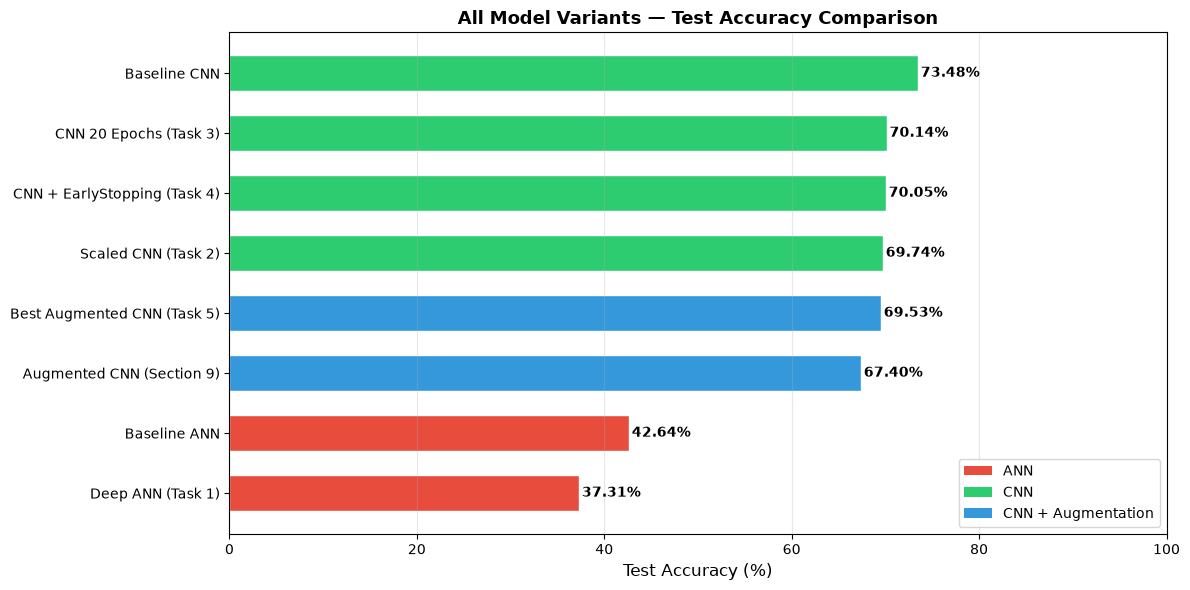

In [36]:

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C' if arch=='ANN' else '#2ECC71' if aug=='No' else '#3498DB'
          for arch, aug in zip(comparison['Architecture'], comparison['Augmentation'])]

bars = ax.barh(comparison['Model'], comparison['Test Accuracy (%)'], 
               color=colors, edgecolor='white', height=0.6)

for bar, acc in zip(bars, comparison['Test Accuracy (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('All Model Variants — Test Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='ANN'),
    Patch(facecolor='#2ECC71', label='CNN'),
    Patch(facecolor='#3498DB', label='CNN + Augmentation'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

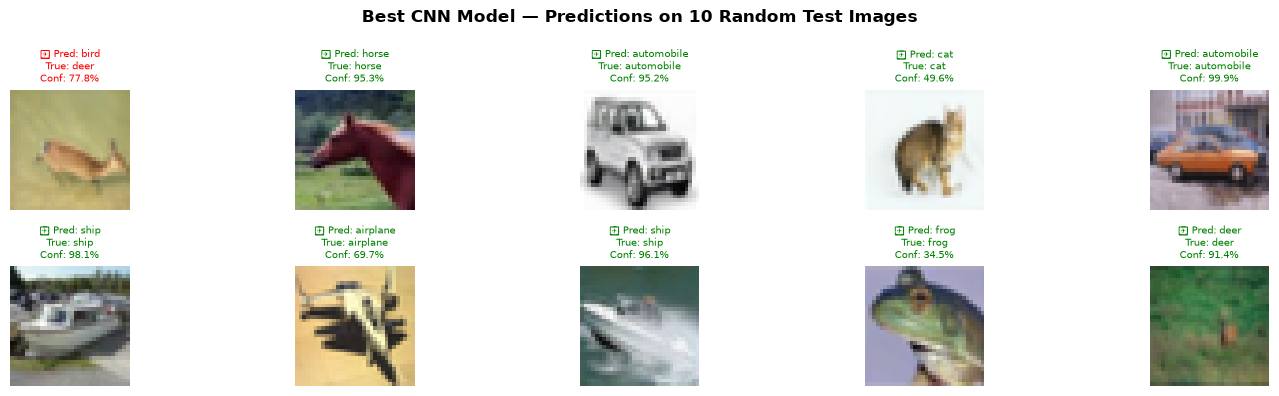


Correct predictions: 9/10


In [37]:


best_model = aug_cnn_final  


random_indices = np.random.choice(len(x_test_norm), 10, replace=False)
sample_images = x_test_norm[random_indices]
true_labels = y_test[random_indices].flatten()


predictions = best_model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
confidence = np.max(predictions, axis=1)

plt.figure(figsize=(15, 4))
plt.suptitle('Best CNN Model — Predictions on 10 Random Test Images', 
             fontsize=12, fontweight='bold')

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample_images[i])
    correct = predicted_labels[i] == true_labels[i]
    color = 'green' if correct else 'red'
    symbol = '✅' if correct else '❌'
    plt.title(
        f'{symbol} Pred: {classes[predicted_labels[i]]}\n'
        f'True: {classes[true_labels[i]]}\n'
        f'Conf: {confidence[i]*100:.1f}%',
        color=color, fontsize=7
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

correct_count = np.sum(predicted_labels == true_labels)
print(f"\nCorrect predictions: {correct_count}/10")